En este trabajo se estudia el problema de contorno dado por:
		$$\frac{1}{\alpha} \frac{\partial T(x,t)}{\partial t}=\frac{\partial^2 T(x,t)}{\partial x^2}-\sigma^2 T(x,t)+f(x) \ , \ 0<x<L \ , \ 0<t<t_{max}$$
		$$\frac{\partial T(0,t)}{\partial x}=\beta T(0)-\gamma $$
		$$T(L,t)=\delta \ , \ 0<t<t_{max} $$
		$$f(x)=F_0 e^{-\mu x} \ , \ 0<t<t_{max}$$
La parte espacial se discretiza mediante diferencias finitas de segundo orden. La condició de Robin se discretiza con la ayuda del nodo fantasma. La integración temporal se realiza mediante el métod de Crank-Nicolson.

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`
[ Info: Saved animation to /home/antonibancells/Desktop/Codi/TFM/Proves Modernes/evolucion_termica.gif


Plots.AnimatedGif("/home/antonibancells/Desktop/Codi/TFM/Proves Modernes/evolucion_termica.gif")
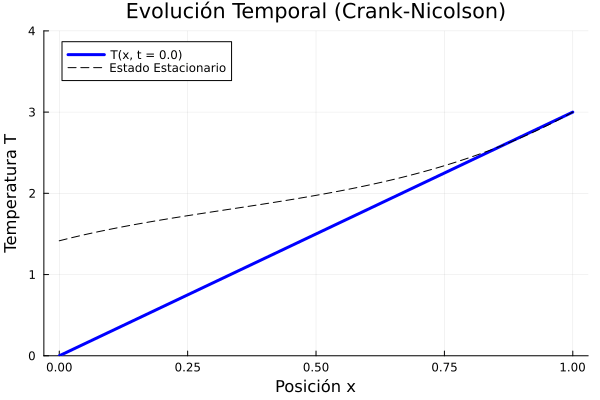

In [1]:
# ==========================================
# PREPARACIÓN DEL ENTORNO
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

using LinearAlgebra
using Plots

function simular_evolucion_temporal()
    # PARÁMETROS DEL PROBLEMA
    L, σ, β, γ, δ = 1.0, 2.0, 1.5, 0.5, 3.0
    F0, μ = 10.0, 1.0
    alpha = 2.0       # Parámetro alpha
    
    # Discretización espacial
    N = 100
    dx = L / N
    x_nodos = collect(0:dx:L)
    
    # Discretización temporal
    dt = 0.0025
    t_final = 0.25
    pasos_t = Int(t_final / dt)

    # CONSTRUCCIÓN DE LA MATRIZ A Y VECTOR b (Estado Estacionario)
    dv = zeros(N)     # Diagonal principal
    ev = zeros(N - 1) # Subdiagonal
    b = zeros(N)
    f(x) = F0 * exp(-μ * x)

    # Nodo i = 0 (Robin con nodo fantasma)
    dv[1] = -(1/dx^2 + β/dx + σ^2/2)
    ev[1] = 1/dx^2
    b[1] = -f(0)/2 - γ/dx

    # Nodos internos i = 1 a N-2
    for i in 2:N-1
        xi = (i-1) * dx
        dv[i] = -(2/dx^2 + σ^2) 
        ev[i] = 1/dx^2 
        b[i] = -f(xi)
    end

    # Nodo i = N-1 (conecta con Dirichlet T_N = δ)
    dv[N] = -(2/dx^2 + σ^2)
    b[N] = -f((N-1)*dx) - δ/dx^2

    A = SymTridiagonal(dv, ev)
    T_estacionaria = [A \ b; δ]

    # PRE-FACTORIZACIÓN DE CRANK-NICOLSON
    # (I - dt * alpha / 2 * A) * T_m+1 = (I + dt * alpha / 2 * A) * T_m - (dt * alpha) * b
    coeff = dt * alpha / 2.0
    M_lhs = I - coeff * A    # Matriz del sistema (Simétrica Definida Positiva)
    M_rhs = I + coeff * A    # Matriz para el paso explícito
    
    # Factorización de Cholesky
    M_fact = cholesky(M_lhs)

    # 4. BUCLE TEMPORAL Y ANIMACIÓN
    # Condición inicial compatible:
    T_actual = [ (i-1)*dx * (δ/L) for i in 1:N ]
    
    anim = @animate for m in 0:pasos_t
        # Graficar estado actual
        plot(x_nodos, [T_actual; δ], lw=3, color=:blue, 
             title="Evolución Temporal (Crank-Nicolson)", 
             label="T(x, t = $(round(m*dt, digits=2)))",
             xlabel="Posición x", ylabel="Temperatura T",
             ylim=(0, 4), grid=:both)
        plot!(x_nodos, T_estacionaria, lw=1, ls=:dash, color=:black, label="Estado Estacionario")
        
        # Siguiente paso: Resolver sistema tridiagonal
        if m < pasos_t
            # Lado derecho: c = M_rhs * T_m - (dt * alpha) * b
            c = M_rhs * T_actual - (dt * alpha) * b
            T_actual = M_fact \ c
        end
    end

    gif(anim, "evolucion_termica.gif", fps=10)
end

simular_evolucion_temporal()